# Notebook 4: Whole-Timeline Realistic Curves And Overfitting Checks

This notebook is aligned to the **current realistic assumptions** used in the `.py` path for label mode, horizon, cadence, and execution realism. It then compares notebook-level frozen hybrid variants on top of those assumptions and adds a final untouched 2025 holdout comparison.

Current realistic assumptions used here:
- `label_mode = baseline_trade`
- `horizon_mins = 60`
- `decision_freq_mins = 30`
- `first_trade_time = 10:00`
- `use_next_bar_open = True`
- `minute_stop_monitoring = True`
- `spread_bps = 1.0`

Frozen variants compared:
- `baseline`
- `soft_base`
- `soft_hybrid_5`
- `soft_hybrid_7_5`
- `soft_hybrid_10`

So this notebook is aligned on assumptions, but it is still a notebook-level robustness comparison rather than the default CLI surface.


In [ ]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

INITIAL_AUM = 100000.0
cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'README.md').exists() and (p / 'src').exists()), cwd)
root = repo / 'reports/model_selection/notebook4_current_defaults'
plot_dir = root / 'plots'

whole_summary = pd.read_csv(root / 'whole_summary.csv')
holdout_summary = pd.read_csv(root / 'holdout_summary.csv')
whole_summary['total_return_pct'] = (whole_summary['final_equity'] / INITIAL_AUM - 1.0) * 100.0
holdout_summary['total_return_pct'] = (holdout_summary['final_equity'] / INITIAL_AUM - 1.0) * 100.0

def show_plot(filename: str) -> None:
    path = plot_dir / filename
    if not path.exists():
        raise FileNotFoundError(f'Missing plot: {path}')
    display(Image(filename=str(path)))

display(whole_summary[['variant','final_equity','total_return_pct','sharpe','max_drawdown','trades_count','turnover','total_costs']].sort_values(['sharpe','final_equity'], ascending=[False, False]))


## What Each Variant Does

- `baseline`: realistic baseline only.
- `soft_base`: baseline direction plus ML soft sizing.
- `soft_hybrid_5`: same ML sizing, but minute stop breaches only trigger immediately when they are catastrophic by 5 bps; otherwise the normal stop remains decision-time confirmed.
- `soft_hybrid_7_5`: same hybrid mechanism with a 7.5 bps catastrophic threshold.
- `soft_hybrid_10`: same hybrid mechanism with a 10 bps catastrophic threshold.

The hybrid family tries to reduce noisy stop-outs and the churn they create while preserving a hard emergency stop.

## Whole-Timeline Equity And Cumulative Return


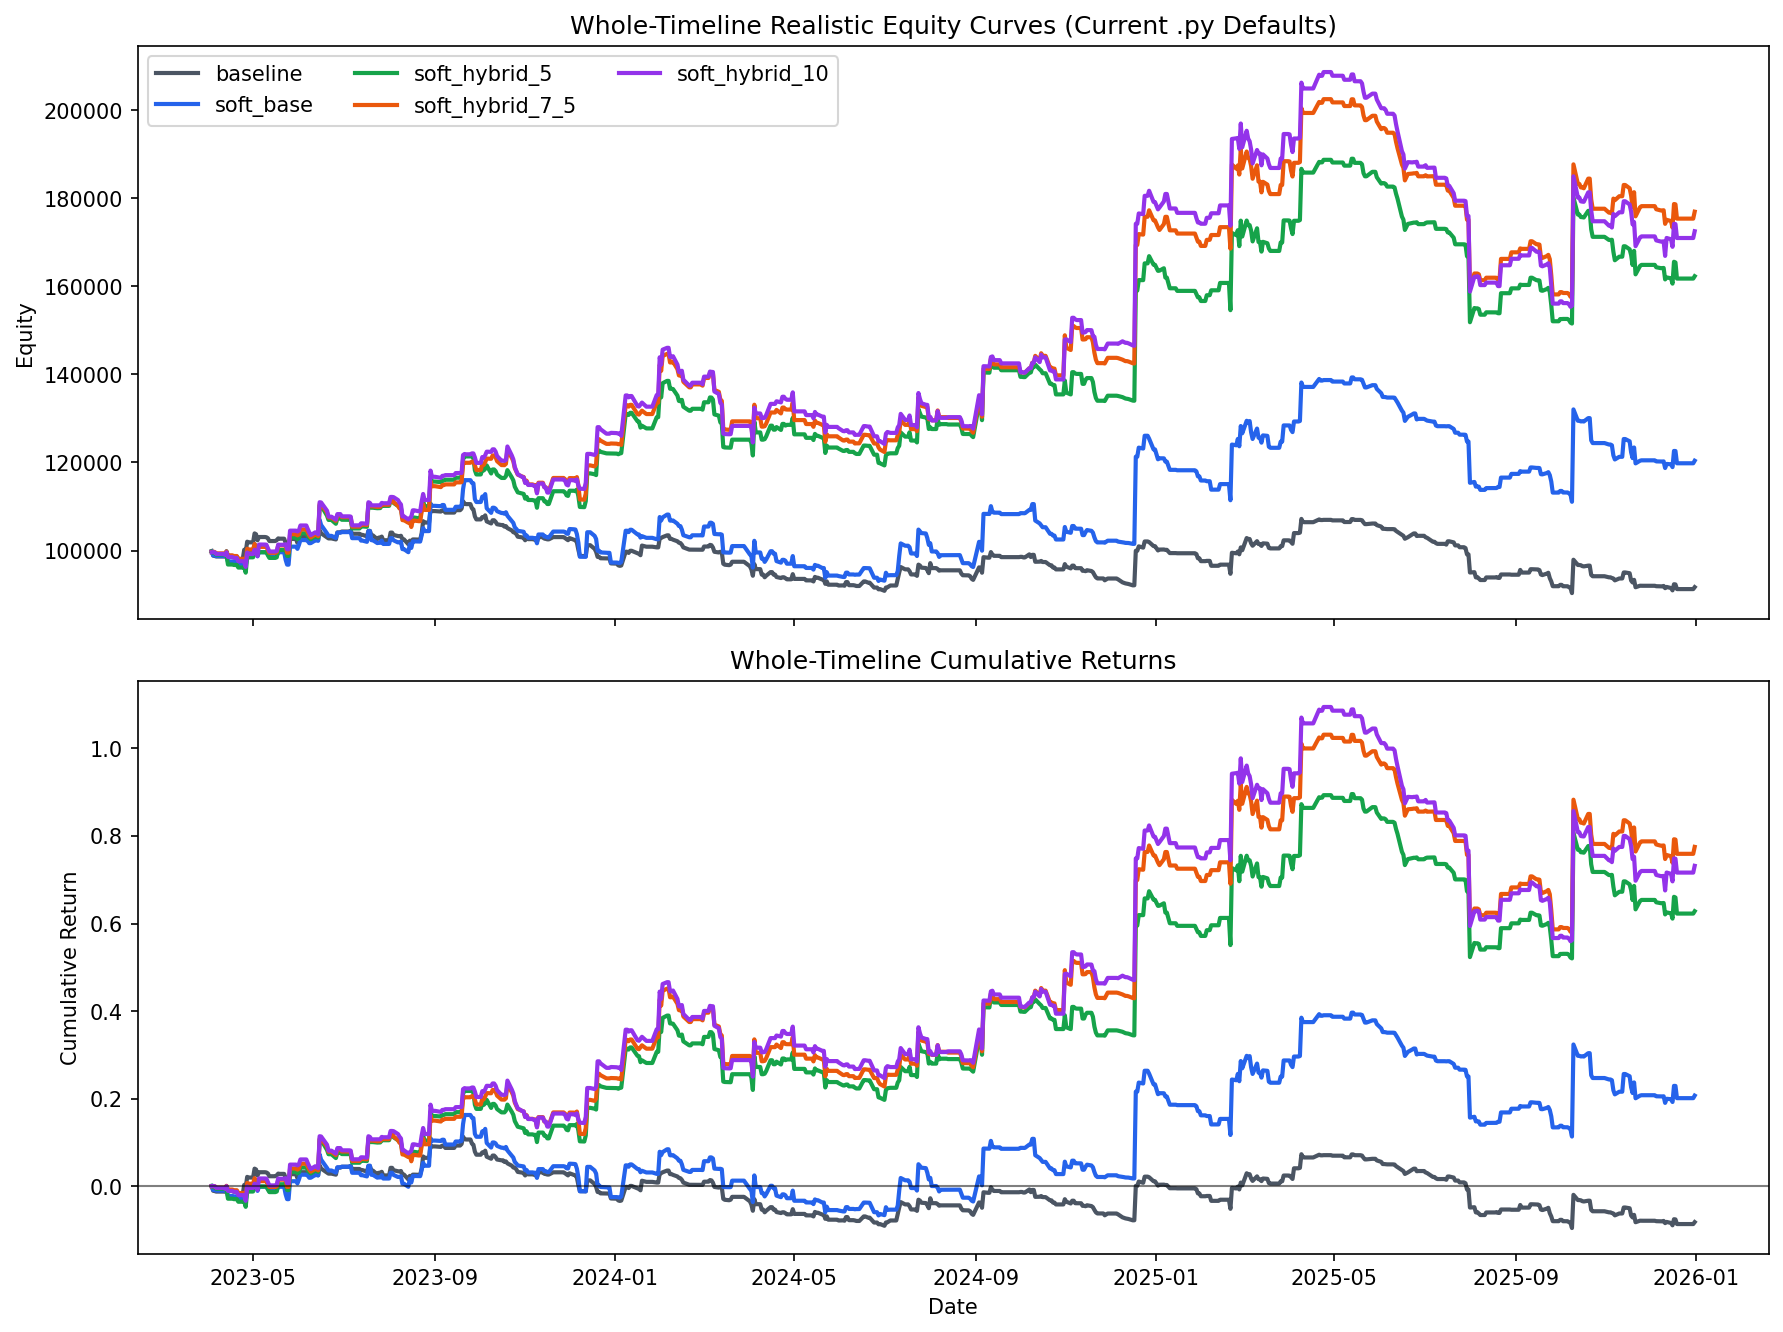

In [1]:
show_plot('whole_timeline_equity_and_cum_return.png')


## Whole-Timeline Drawdowns


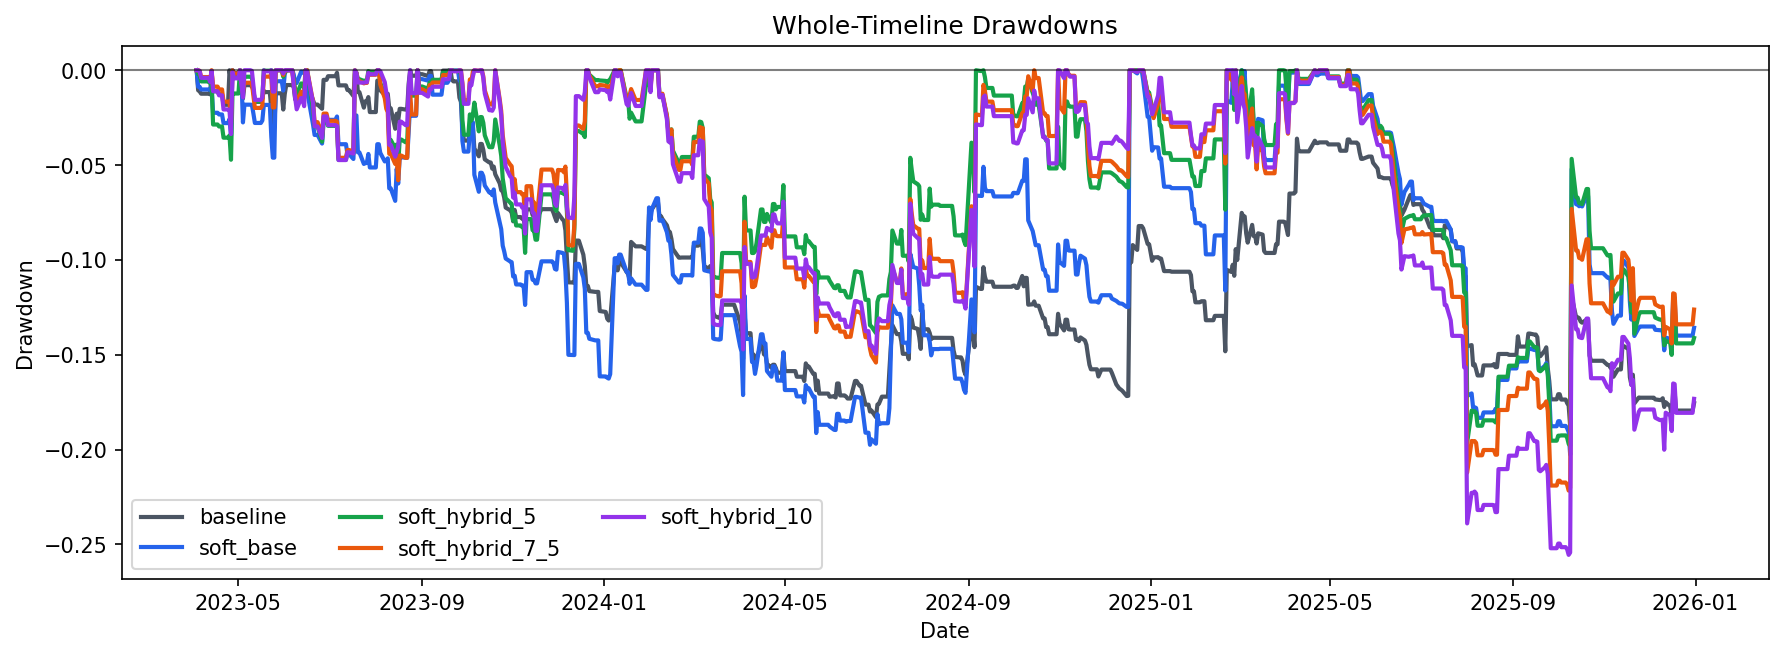

In [1]:
show_plot('whole_timeline_drawdowns.png')


## Whole-Timeline Rolling 20-Day Return


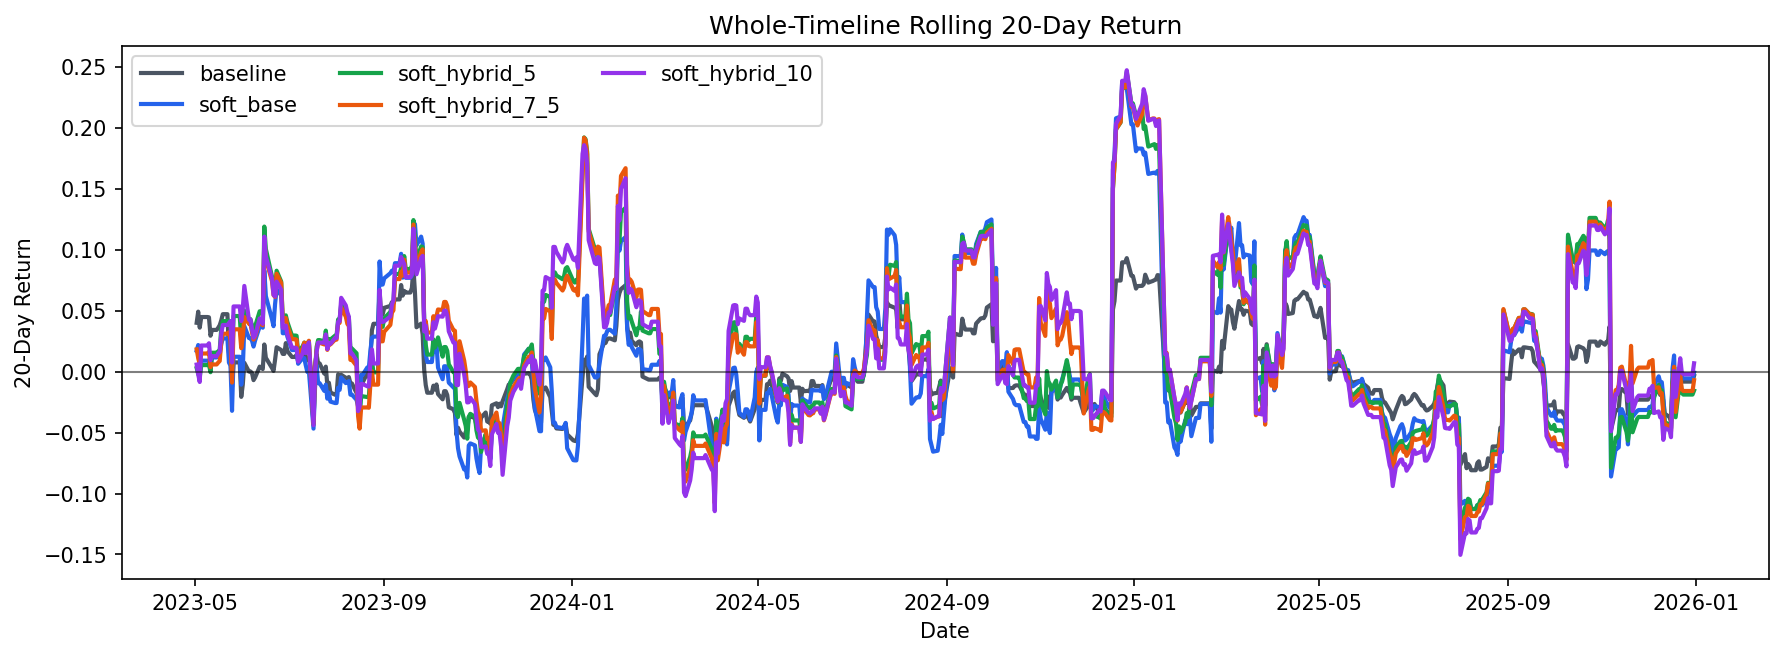

In [1]:
show_plot('whole_timeline_rolling_20d_return.png')


## Headline Metrics On The Whole Timeline


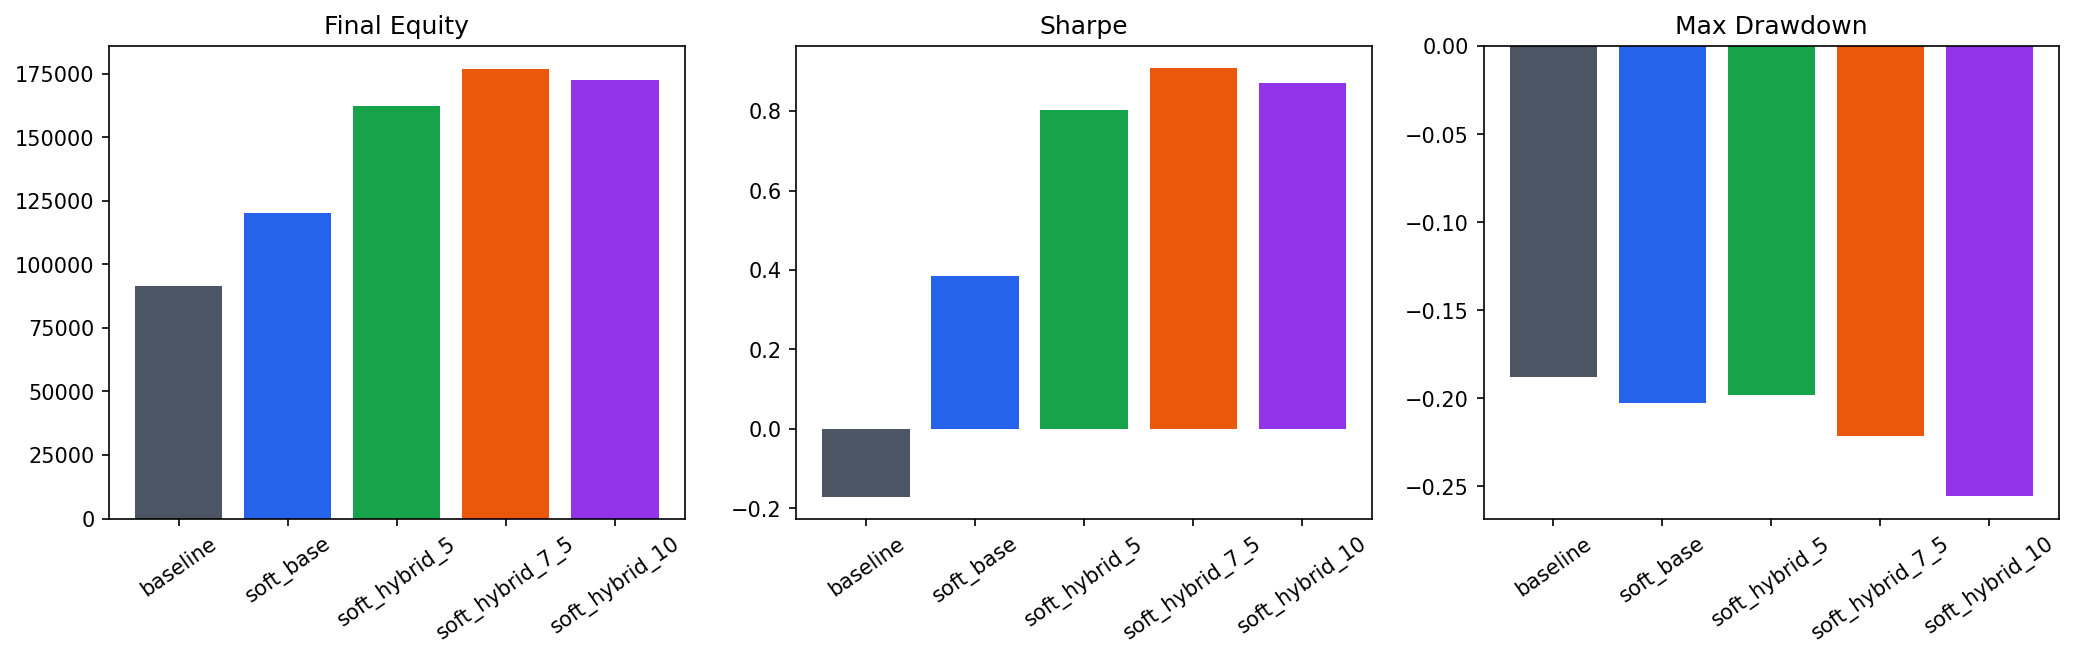

In [1]:
show_plot('whole_timeline_metric_bars.png')


## Overfitting Checks

These checks are based on the same `.py` defaults, so the notebook metrics and the code path are now directly comparable.

1. **Split stability**: do the variants keep positive Sharpe across many walk-forward splits, or do they rely on a few windows?
2. **Parameter sensitivity**: is performance broad across nearby catastrophic-stop values, or does it spike at one narrow setting?
3. **Holdout gap**: how much of the whole-timeline edge survives on the untouched 2025 holdout?

### Split-by-Split Sharpe


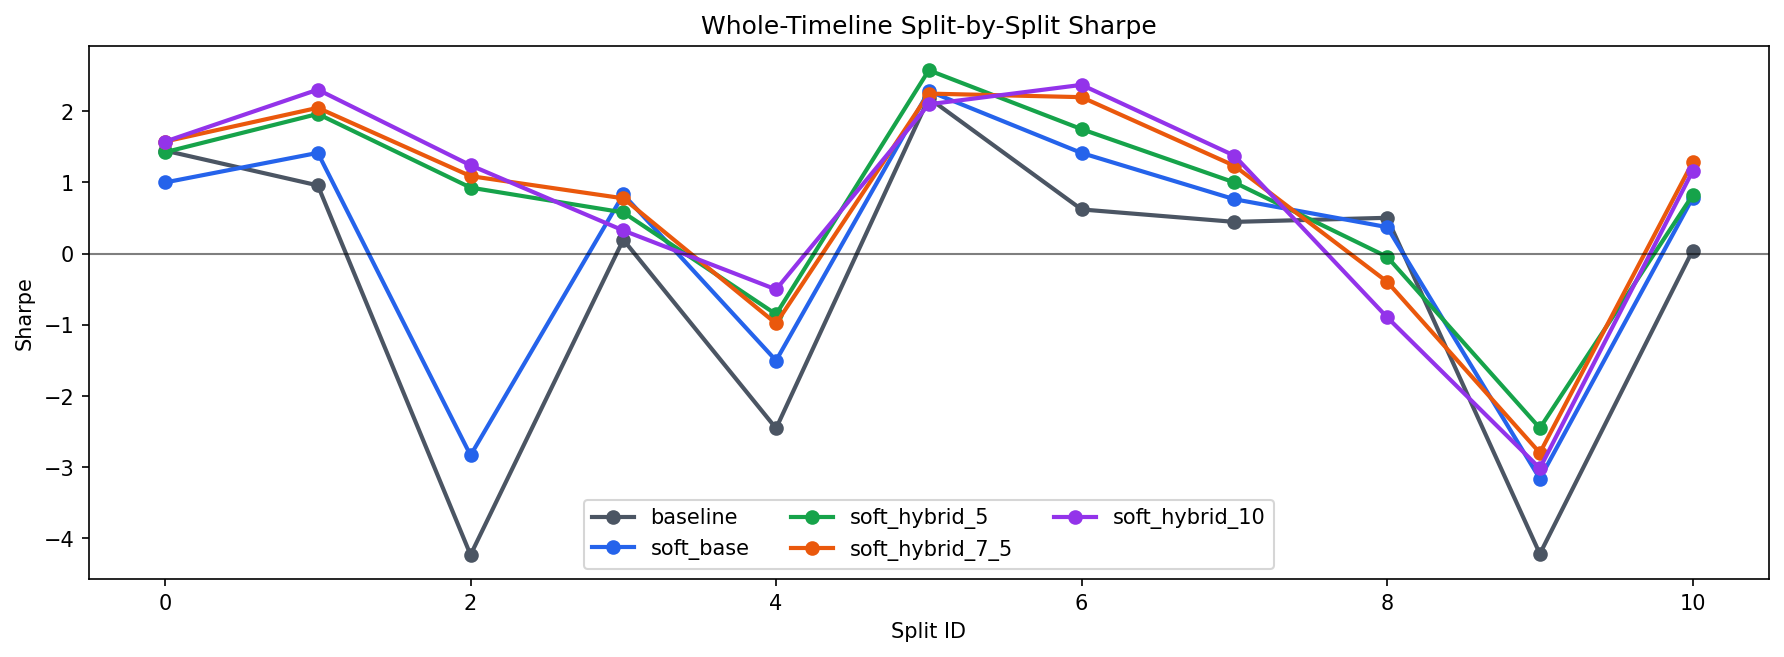

In [1]:
show_plot('whole_timeline_split_sharpe.png')


### Hybrid Threshold Sensitivity


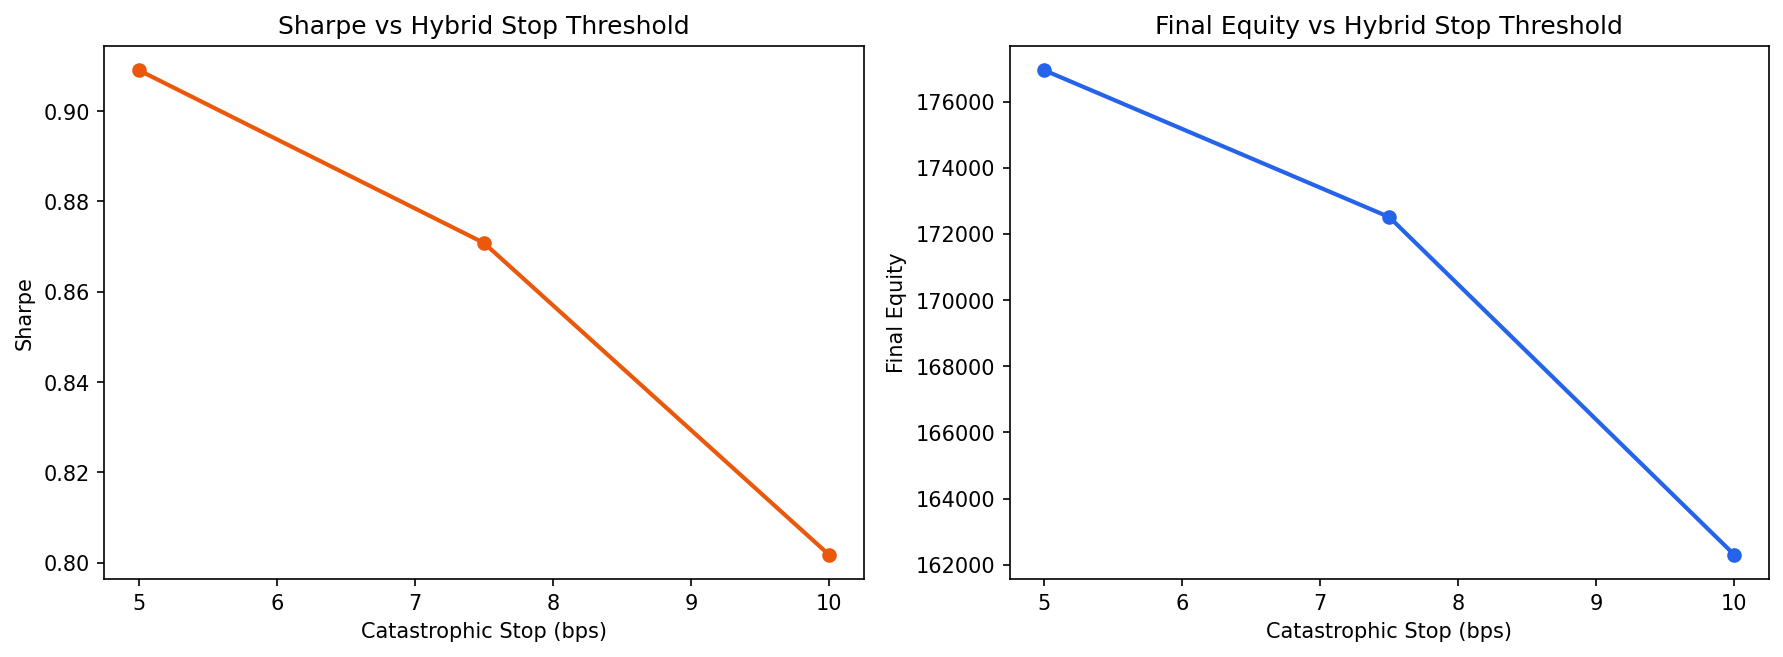

In [1]:
show_plot('whole_timeline_hybrid_sensitivity.png')


In [ ]:
compare = pd.read_csv(root / 'whole_vs_holdout_compare.csv')
compare['whole_total_return_pct'] = (compare['final_equity'] / INITIAL_AUM - 1.0) * 100.0
compare['holdout_total_return_pct'] = (compare['holdout_final_equity'] / INITIAL_AUM - 1.0) * 100.0
compare['return_gap_pct'] = compare['whole_total_return_pct'] - compare['holdout_total_return_pct']
display(compare[['variant','final_equity','whole_total_return_pct','holdout_final_equity','holdout_total_return_pct','equity_gap','return_gap_pct','sharpe','holdout_sharpe','sharpe_gap','max_drawdown','holdout_max_drawdown']].sort_values('sharpe', ascending=False))


### Whole-Timeline vs Holdout Degradation


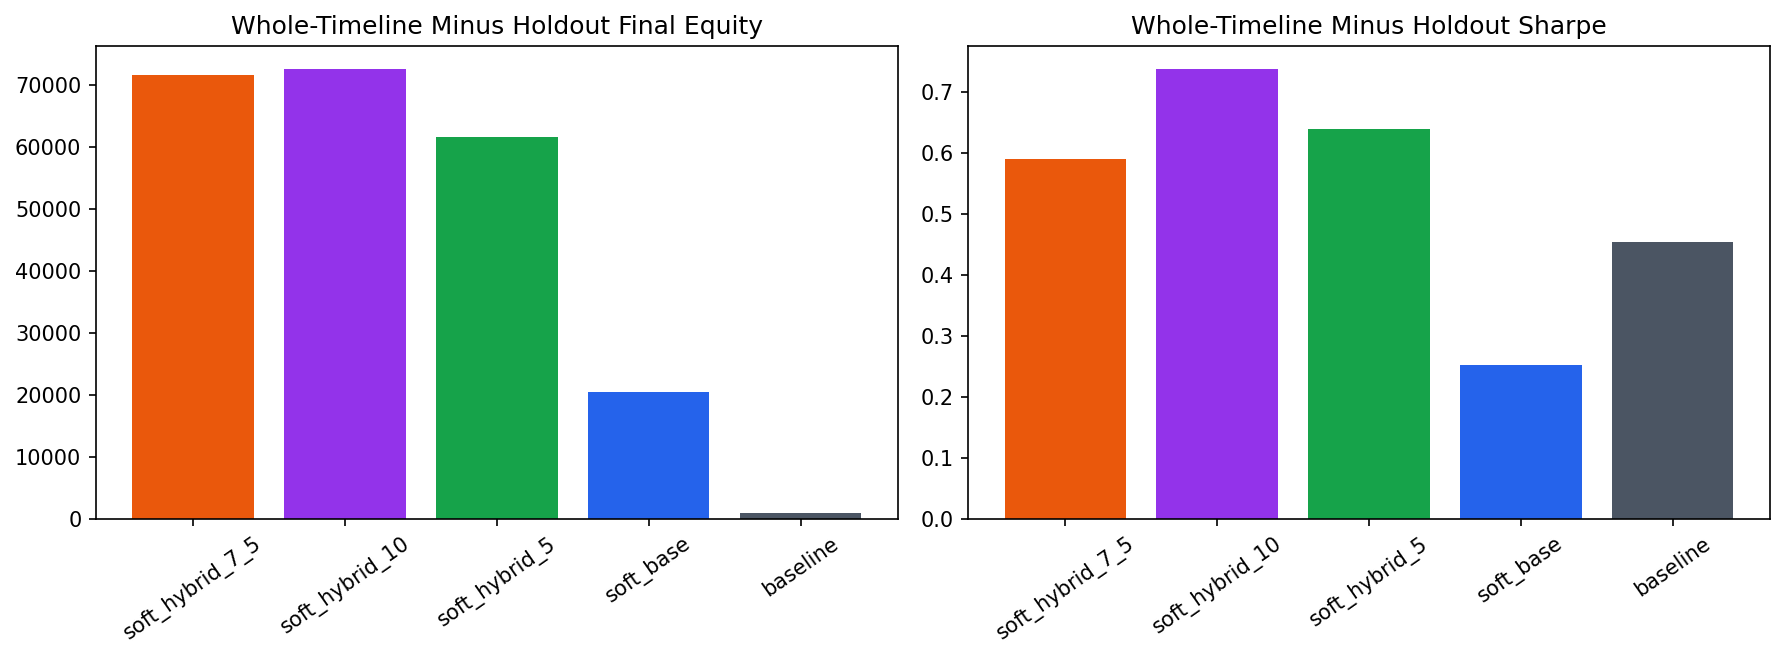

In [1]:
show_plot('whole_vs_holdout_gap.png')


## Interpretation

With the current realistic assumptions, the notebook and the code path are aligned on the underlying execution model and label configuration.

On the whole timeline:
- `soft_hybrid_7_5` is the top frozen variant by Sharpe and final equity;
- the full hybrid family beats `soft_base` and `baseline`.

On the untouched 2025 holdout:
- `soft_hybrid_7_5` remains the best of the frozen set;
- the edge compresses materially, so the mechanism looks useful but the exact threshold is still selection-sensitive.

Correct takeaway:
- trust the **hybrid-stop mechanism** more than the exact tuned threshold;
- use this notebook as the anti-overfit check for the realistic improvement search, not as proof that the exact threshold is permanently optimal.
